# Waiter–month feature selection

Pipeline mirrors `A_tuning/features_selection.ipynb` (**waiter–week**), on **waiter–month** rows from `config.load_data` (`num_of_trn_month=0`, index = waiter–month id). Fraud labels are waiter–months that contain at least one labeled fraud week (`FRAUD_WAITER_WEEK_IDS` → month start).

1. **Variance filter** — drop near-constant numeric columns.
2. **ANOVA** — `f_classif`, same filtering as `avona.ipynb`.
3. **Random forest importances** — on the scaled synthetic-fraud train setup.
4. **Correlation filter** — on non-fraud data, keep higher-MDI survivor (Step 3b).
5. **Permutation importance (`precision@50`)** — IF / OCSVM / LOF on `features_after_correlation` (Step 3c).
6. **Backward RFE** — lowest-importance removals first; guard via `RFE_REMOVAL_GUARD` (Step 4a–4d).

**Options:** In Step 4a set `RFE_IMPORTANCE_SOURCE` to `"rf"`, `"perm_iso"`, `"perm_ocsvm"`, or `"perm_lof"`.

Run cells in order.


In [1]:
"""Shared setup: load waiter–month data, leakage-safe preprocessing, synthetic-fraud helpers (same design as `features_selection.ipynb` for waiter–week)."""
import os
import sys
import warnings
from typing import Optional

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

_project_root = os.path.abspath("..")
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from models.scaling import scale_features, _auto_skewed_columns
from config import load_data
from parquet.fraud_ids import FRAUD_WAITER_WEEK_IDS

# --- Same defaults as gini_features_importance.ipynb / features_selection.ipynb ---
MIN_NUM_OF_TRN = 8
WORKING_DAYS = 2
N_SYNTHETIC_FRAUD = 6000
N_SYNTHETIC_FRAUD_TRAIN = int(N_SYNTHETIC_FRAUD * 0.8)
N_SYNTHETIC_FRAUD_TEST = int(N_SYNTHETIC_FRAUD * 0.2)
N_TRAIN_FRAUD_TYPES = 25
NOISE_SCALE = 0.2
RANDOM_STATE = 42
ACTIVITY_STATE = 2
DAYS_VISITS = 2
TEST_SIZE = 0.2
SKEW_ABS_THRESHOLD = 1.0

# Waiter–months that contain at least one labeled fraud week (from FRAUD_WAITER_WEEK_IDS)
FRAUD_WAITER_MONTH_IDS = set()
for _fw in FRAUD_WAITER_WEEK_IDS:
    _wid, _wk = _fw.rsplit("_", 1)
    _month_start = pd.Timestamp(_wk).to_period("M").start_time
    FRAUD_WAITER_MONTH_IDS.add(f"{_wid}_{_month_start.strftime('%Y-%m-%d')}")

_, _, _, waiter_month_data, _ = load_data(
    activity_state=ACTIVITY_STATE,
    days_visits=DAYS_VISITS,
    place_num_of_waiters=2,
    num_of_trn_month=0,
)
waiter_month_data = waiter_month_data[
    waiter_month_data["num_of_trn"] >= MIN_NUM_OF_TRN
].copy()
waiter_month_data = waiter_month_data[waiter_month_data["working_days"] >= WORKING_DAYS]

waiter_month_data = waiter_month_data.copy()
waiter_month_data["is_fraud"] = waiter_month_data.index.isin(FRAUD_WAITER_MONTH_IDS).astype(int)
y_fraud = waiter_month_data["is_fraud"].values

features_to_drop = [c for c in waiter_month_data.columns if c.startswith("num_of_fraud")]
waiter_month_data = waiter_month_data.drop(columns=features_to_drop)

waiter_month_data_raw = waiter_month_data.copy()

waiter_month_numeric_all = [
    c
    for c in waiter_month_data.select_dtypes(include=[np.number]).columns
    if c != "is_fraud"
]

num_cols = waiter_month_data.select_dtypes(include=[np.number]).columns
non_fraud_df = waiter_month_data[waiter_month_data["is_fraud"] == 0]
for col in num_cols:
    col_nf = non_fraud_df[col]
    finite = col_nf[np.isfinite(col_nf)]
    mean_val = float(finite.mean()) if len(finite) else 0.0
    if not np.isfinite(mean_val):
        mean_val = 0.0
    col_vals = waiter_month_data[col]
    waiter_month_data[col] = np.where(~np.isfinite(col_vals), mean_val, col_vals)

if int(y_fraud.sum()) == 0:
    raise ValueError("No known fraud waiter-months; cannot run this pipeline.")

_RATE_BOUNDS_ATOL = 1e-8


def _column_values_in_unit_interval(series: pd.Series) -> bool:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return False
    lo, hi = float(s.min()), float(s.max())
    return lo >= -_RATE_BOUNDS_ATOL and hi <= 1.0 + _RATE_BOUNDS_ATOL


def synthesize_fraud_only(
    fraud_source: pd.DataFrame,
    n_synthetic: int,
    noise_scale: float = 0.1,
    rate_noise_scale: Optional[float] = None,
    random_state: int = 42,
    id_label: Optional[str] = None,
) -> pd.DataFrame:
    if len(fraud_source) == 0:
        raise ValueError("fraud_source is empty; cannot synthesize fraud.")
    synthetic = fraud_source.sample(
        n=n_synthetic, replace=True, random_state=random_state
    ).copy()
    num_cols_local = synthetic.select_dtypes("number").columns.difference(
        ["is_fraud"], sort=False
    )
    if "person_id" in synthetic.columns:
        num_cols_local = num_cols_local.difference(["person_id"], sort=False)
    if "waiter_id" in synthetic.columns:
        num_cols_local = num_cols_local.difference(["waiter_id"], sort=False)
    num_cols_local = list(num_cols_local)
    if rate_noise_scale is None:
        rate_noise_scale = noise_scale * 0.25
    col_std = np.array(
        [
            rate_noise_scale
            if _column_values_in_unit_interval(fraud_source[c])
            else noise_scale
            for c in num_cols_local
        ],
        dtype=float,
    )
    rng = np.random.default_rng(random_state)
    noise = rng.normal(0, 1, (len(synthetic), len(num_cols_local))) * col_std
    synthetic.loc[:, num_cols_local] = synthetic[num_cols_local].values * (1 + noise)
    synthetic["is_fraud"] = 1
    synthetic["synthetic"] = 1
    prefix = (
        f"__synthetic_fraud__{id_label}_{random_state}_"
        if id_label
        else f"__synthetic_fraud__{random_state}_"
    )
    synthetic.index = [f"{prefix}{i}" for i in range(len(synthetic))]
    synthetic.index.name = fraud_source.index.name
    return synthetic


def build_fraud_type_generalization_datasets(
    wm: pd.DataFrame,
    *,
    n_train_fraud_types: int,
    n_synthetic_fraud_train: int,
    n_synthetic_fraud_test: int,
    noise_scale: float,
    test_size_non_fraud: float,
    random_state: int,
):
    fraud_mask = wm["is_fraud"] == 1
    fraud_types = wm.index[fraud_mask].unique().tolist()
    if len(fraud_types) < 2:
        raise ValueError(
            "Need at least 2 distinct fraud waiter-month rows for disjoint train/test fraud pools."
        )
    rng = np.random.RandomState(random_state)
    order = list(fraud_types)
    rng.shuffle(order)
    n_take_train = min(int(n_train_fraud_types), len(order) - 1)
    n_take_train = max(1, n_take_train)
    train_type_set = set(order[:n_take_train])
    test_type_set = set(order[n_take_train:])

    fraud_train_pool = wm.loc[fraud_mask & wm.index.isin(train_type_set)]
    fraud_test_pool = wm.loc[fraud_mask & wm.index.isin(test_type_set)]

    non_fraud = wm.loc[~fraud_mask]
    idx_nf_train, idx_nf_test = train_test_split(
        non_fraud.index,
        test_size=test_size_non_fraud,
        random_state=random_state,
    )
    nf_train = wm.loc[idx_nf_train].copy()
    nf_test = wm.loc[idx_nf_test].copy()
    nf_train["synthetic"] = 0
    nf_test["synthetic"] = 0

    syn_train = synthesize_fraud_only(
        fraud_train_pool,
        n_synthetic=n_synthetic_fraud_train,
        noise_scale=noise_scale,
        random_state=random_state,
        id_label="train_types",
    )
    syn_test = synthesize_fraud_only(
        fraud_test_pool,
        n_synthetic=n_synthetic_fraud_test,
        noise_scale=noise_scale,
        random_state=random_state + 1,
        id_label="test_types_only",
    )
    train_df = pd.concat([nf_train, syn_train])
    test_df = pd.concat([nf_test, syn_test])
    full_df = pd.concat([train_df, test_df])
    meta = {
        "n_fraud_types": len(fraud_types),
        "n_train_fraud_types": len(train_type_set),
        "n_test_fraud_types": len(test_type_set),
    }
    return train_df, test_df, full_df, meta


def build_scaled_train_test(feature_list: list[str]):
    """Scaled X_train/X_test and y for a given feature list (gini-style)."""
    train_df, test_df, synthetic, split_meta = build_fraud_type_generalization_datasets(
        waiter_month_data,
        n_train_fraud_types=N_TRAIN_FRAUD_TYPES,
        n_synthetic_fraud_train=N_SYNTHETIC_FRAUD_TRAIN,
        n_synthetic_fraud_test=N_SYNTHETIC_FRAUD_TEST,
        noise_scale=NOISE_SCALE,
        test_size_non_fraud=TEST_SIZE,
        random_state=RANDOM_STATE,
    )
    idx_train = train_df.index
    idx_test = test_df.index
    train_non_fraud = synthetic.loc[idx_train]
    train_non_fraud = train_non_fraud[train_non_fraud["is_fraud"] == 0]
    if len(train_non_fraud) == 0:
        raise ValueError("Train split has no non-fraud rows.")
    impute_ref = train_non_fraud
    skewed = _auto_skewed_columns(synthetic, feature_list, SKEW_ABS_THRESHOLD)
    _, X_scaled = scale_features(
        data=synthetic,
        features=feature_list,
        scaler_type="standard",
        skew_abs_threshold=SKEW_ABS_THRESHOLD,
        fit_data=train_non_fraud,
        impute_reference=impute_ref,
    )
    X_train = X_scaled.loc[idx_train].values.astype(np.float64)
    X_test = X_scaled.loc[idx_test].values.astype(np.float64)
    y_train = synthetic.loc[idx_train, "is_fraud"].astype(int).values
    y_test = synthetic.loc[idx_test, "is_fraud"].astype(int).values
    return X_train, X_test, y_train, y_test, skewed, split_meta


print(
    f"Loaded waiter_month rows={len(waiter_month_data)}, fraud={int(y_fraud.sum())}, "
    f"numeric feature candidates={len(waiter_month_numeric_all)}"
)



Loaded waiter_month rows=17786, fraud=22, numeric feature candidates=195


## Step 1 — variance filter

Drop numeric columns whose variance is below `MIN_VARIANCE`.


In [2]:
MIN_VARIANCE = 1e-8

X_var = waiter_month_data[waiter_month_numeric_all].astype(float)
col_var = X_var.var(axis=0, skipna=True)
features_after_variance = col_var[col_var >= MIN_VARIANCE].index.tolist()
n_dropped = len(waiter_month_numeric_all) - len(features_after_variance)
print(
    f"Step 1 (variance ≥ {MIN_VARIANCE:g}): kept {len(features_after_variance)} / {len(waiter_month_numeric_all)} features; dropped {n_dropped} low-variance columns."
)



Step 1 (variance ≥ 1e-08): kept 195 / 195 features; dropped 0 low-variance columns.


## Step 2 — ANOVA (`f_classif`)

Same filtering as `avona.ipynb`: finite rows; drop constant columns; significance α = 0.05 (same survivor rule as waiter–week notebook).


In [3]:
from sklearn.feature_selection import f_classif

try:
    from IPython.display import display
except ImportError:
    display = print

y = waiter_month_data["is_fraud"].astype(int)
X = waiter_month_data[features_after_variance].replace([np.inf, -np.inf], np.nan)
complete = np.isfinite(X.to_numpy(dtype=float)).all(axis=1)
X_use = X.loc[complete]
y_use = y.loc[complete]

n_fraud = int(y_use.sum())
n_ok = int((y_use == 0).sum())
print(f"Rows for ANOVA (all finite): {len(X_use)} (fraud={n_fraud}, non-fraud={n_ok})")

if n_fraud < 2 or n_ok < 2:
    raise ValueError("Need at least 2 samples in each class for ANOVA.")

std = X_use.std()
numeric_cols_fit = [c for c in features_after_variance if std[c] > 0 and np.isfinite(std[c])]
if len(numeric_cols_fit) < len(features_after_variance):
    print(f"Dropped {len(features_after_variance) - len(numeric_cols_fit)} constant column(s) before ANOVA.")

F_scores, p_values = f_classif(X_use[numeric_cols_fit], y_use)
means_fraud = X_use.loc[y_use == 1, numeric_cols_fit].mean()
means_nonfraud = X_use.loc[y_use == 0, numeric_cols_fit].mean()

anova_results = (
    pd.DataFrame(
        {
            "feature": numeric_cols_fit,
            "F_score": F_scores,
            "p_value": p_values,
            "mean_fraud": means_fraud.values,
            "mean_nonfraud": means_nonfraud.values,
        }
    )
    .sort_values("p_value", kind="mergesort")
    .reset_index(drop=True)
)
anova_results["significant_0.05"] = anova_results["p_value"] < 0.05
anova_results["significant_bonferroni_0.05"] = anova_results["p_value"] < (
    0.05 / len(numeric_cols_fit)
)

features_after_anova = anova_results.loc[
    anova_results["significant_0.05"], "feature"
].tolist()
print(f"Step 2 (Bonferroni): kept {len(features_after_anova)} significant features.")
if len(features_after_anova) == 0:
    print("Warning: no features passed Bonferroni; consider relaxing to significant_0.05 for exploration.")

display(anova_results.head(40))



Rows for ANOVA (all finite): 17786 (fraud=22, non-fraud=17764)
Step 2 (Bonferroni): kept 37 significant features.


,feature,F_score,p_value,mean_fraud,mean_nonfraud,significant_0.05,significant_bonferroni_0.05
0,top1_client_trn,173.156105,2.311249e-39,16.727273,4.151092,True,True
1,trn_per_person_norm,118.939555,1.320470e-27,1.275746,1.023388,True,True
2,top1_client_trn_diff_prev,92.047152,9.554716e-22,7.409091,1.495046,True,True
3,trn_per_person_norm_diff_prev,57.704948,3.196111e-14,0.210335,0.054749,True,True
4,top1_client_share_norm,53.600450,2.561909e-13,2.755800,1.134316,True,True
5,top1_client_share,42.427263,7.532611e-11,0.124582,0.051446,True,True
6,share_trn_top_waiter,41.347043,1.307098e-10,0.449648,0.248228,True,True
7,trn_per_person,40.117610,2.448598e-10,1.499747,1.185895,True,True
8,trn_per_person_diff_prev,32.127614,1.466088e-08,0.222443,0.068718,True,True
9,top1_client_trn_diff_next,31.951738,1.604749e-08,4.954545,1.488066,True,True


## Step 3 — Random Forest feature importances


Step 3: train shape (19011, 37), test shape (4753, 37); log1p cols=23; fraud types train/test: 21/1
Step 3: RandomForest feature_importances_ (train fit, MDI).


,feature,importance
0,top1_client_share,0.156660
1,top1_client_trn,0.126528
2,top1_client_share_norm,0.079284
3,share_trn_top_waiter,0.055157
4,trn_per_person_norm,0.055077
5,share_loyal_trn,0.053476
6,share_unique_clients,0.044185
7,share_clients_top_waiter,0.041623
8,share_of_trn,0.030227
9,share_of_trn_diff_next,0.028752


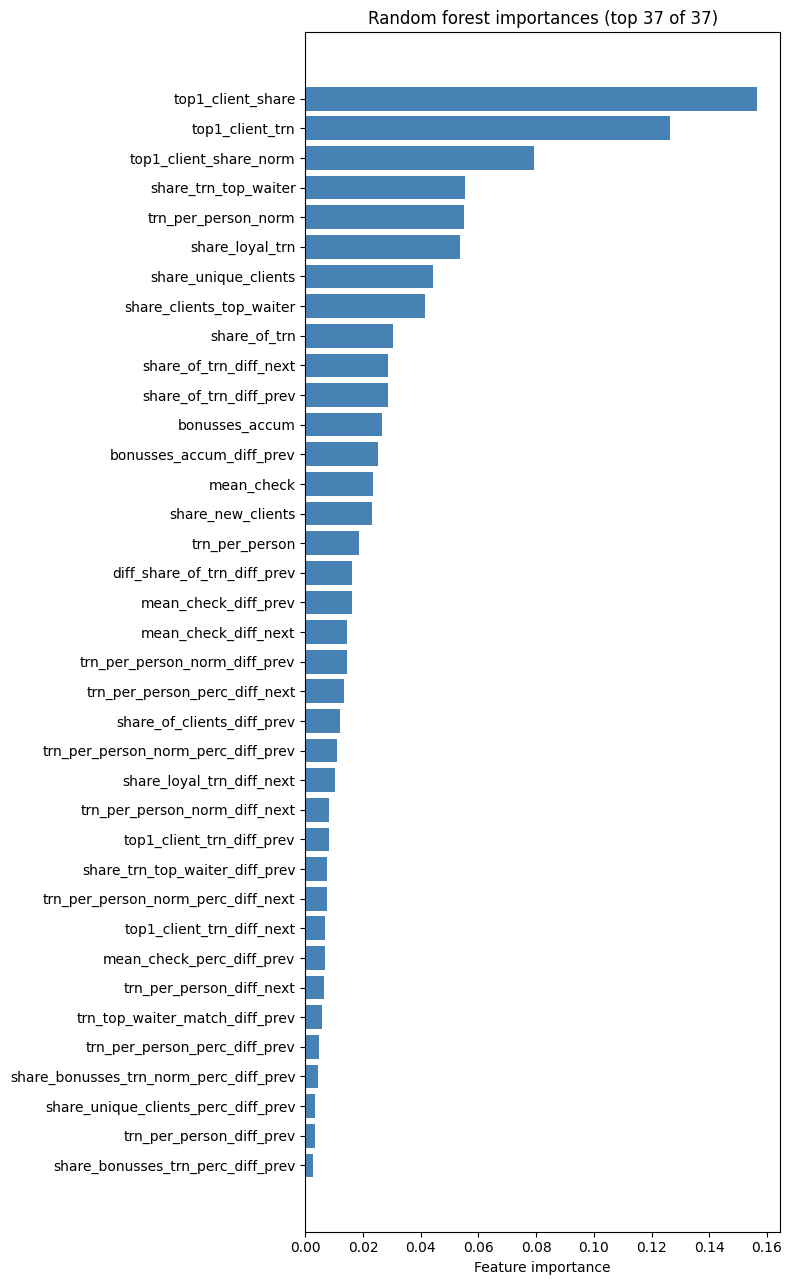

In [4]:
from sklearn.ensemble import RandomForestClassifier

if len(features_after_anova) == 0:
    raise ValueError("No ANOVA-selected features; relax Step 2 or check data.")

X_train, X_test, y_train, y_test, skewed_cols, split_meta = build_scaled_train_test(
    features_after_anova
)
print(
    f"Step 3: train shape {X_train.shape}, test shape {X_test.shape}; "
    f"log1p cols={len(skewed_cols)}; fraud types train/test: "
    f"{split_meta['n_train_fraud_types']}/{split_meta['n_test_fraud_types']}"
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1,
)
rf.fit(X_train, y_train)

rf_importance = (
    pd.DataFrame(
        {"feature": features_after_anova, "importance": rf.feature_importances_}
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
print("Step 3: RandomForest feature_importances_ (train fit, MDI).")
display(rf_importance)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(rf_importance))))
top_n = min(40, len(rf_importance))
plot_df = rf_importance.head(top_n).iloc[::-1]
ax.barh(plot_df["feature"], plot_df["importance"], color="steelblue")
ax.set_xlabel("Feature importance")
ax.set_title(f"Random forest importances (top {top_n} of {len(rf_importance)})")
plt.tight_layout()
plt.show()



## Step 3b — Correlation filter (after Random Forest)

Output: **`features_after_correlation`** — for Step 3c (and optional RFE importance source).


In [5]:
CORR_THRESHOLD = 0.85

_imp_order = rf_importance.sort_values("importance", ascending=False)["feature"].tolist()
_nf = waiter_month_data_raw.loc[~waiter_month_data_raw["is_fraud"].astype(bool), _imp_order].copy()
_nf = _nf.replace([np.inf, -np.inf], np.nan).fillna(_nf.median(numeric_only=True)).fillna(0)
C = _nf.corr().abs()

kept = []
dropped_pairs = []
for f in _imp_order:
    conflict = None
    for s in kept:
        v = C.loc[f, s]
        if pd.notna(v) and float(v) >= CORR_THRESHOLD:
            conflict = s
            break
    if conflict is None:
        kept.append(f)
    else:
        dropped_pairs.append((f, conflict, float(C.loc[f, conflict])))

features_after_correlation = kept
print(
    f"Step 3b: |corr| < {CORR_THRESHOLD} vs kept set; "
    f"kept {len(features_after_correlation)} / {len(_imp_order)} features (non-fraud n={len(_nf)})."
)
if dropped_pairs:
    display(
        pd.DataFrame(
            dropped_pairs,
            columns=["dropped_lower_priority", "kept_correlated_partner", "abs_corr"],
        )
    )



Step 3b: |corr| < 0.85 vs kept set; kept 30 / 37 features (non-fraud n=17764).


,dropped_lower_priority,kept_correlated_partner,abs_corr
0,share_clients_top_waiter,share_trn_top_waiter,0.967607
1,diff_share_of_trn_diff_prev,share_of_trn_diff_prev,0.981462
2,share_of_clients_diff_prev,share_of_trn_diff_prev,0.960258
3,trn_per_person_norm_perc_diff_prev,trn_per_person_norm_diff_prev,0.944772
4,trn_per_person_norm_perc_diff_next,trn_per_person_norm_diff_next,0.944810
5,trn_per_person_diff_next,trn_per_person_perc_diff_next,0.952964
6,trn_per_person_diff_prev,trn_per_person_perc_diff_prev,0.929688


## Step 3c — Permutation importance (`precision@50`)

One cell per anomaly model; hyperparameters match `features_selection.ipynb` / `fit_and_evaluate`.


In [6]:
"""Step 3c — Isolation Forest: permutation importance for precision@50 (features = `features_after_correlation`)."""
from sklearn.ensemble import IsolationForest

from models.fit_and_evaluate import _top_k_precision

PERM_N_REPEATS = 5

waiter_month_perm = waiter_month_data_raw.copy()
y_perm = waiter_month_perm["is_fraud"].astype(int).values
train_perm = waiter_month_perm.loc[~waiter_month_perm["is_fraud"].astype(bool).values]
feat_perm = list(features_after_correlation)

X_fit_df, X_eval_df = scale_features(
    data=waiter_month_perm,
    features=feat_perm,
    scaler_type="standard",
    skew_abs_threshold=SKEW_ABS_THRESHOLD,
    fit_data=train_perm,
)
X_fit_p = X_fit_df.values.astype(np.float64)
X_eval_p = X_eval_df.values.astype(np.float64)


def _precision_at_50(scores: np.ndarray) -> float:
    return float(_top_k_precision(scores, y_perm, [50])["precision@50"])


iso = IsolationForest(
    n_estimators=500,
    contamination=0.0005,
    max_samples=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iso.fit(X_fit_p)
scores_base = -iso.score_samples(X_eval_p)
baseline = _precision_at_50(scores_base)

rows = []
for j, name in enumerate(feat_perm):
    deltas = []
    for r in range(PERM_N_REPEATS):
        rng = np.random.default_rng(RANDOM_STATE + r * 1_000_003 + j)
        X_perm = X_eval_p.copy()
        X_perm[:, j] = rng.permutation(X_perm[:, j])
        scores_j = -iso.score_samples(X_perm)
        deltas.append(baseline - _precision_at_50(scores_j))
    rows.append(
        {
            "feature": name,
            "importance_mean": float(np.mean(deltas)),
            "importance_std": float(np.std(deltas, ddof=0)),
        }
    )

perm_importance_iso = (
    pd.DataFrame(rows)
    .assign(baseline_precision_at_50=baseline)
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
print(
    f"Isolation Forest — baseline precision@50={baseline:.4f} | "
    f"n_features={len(feat_perm)} | perm_repeats={PERM_N_REPEATS}"
)
display(perm_importance_iso)



Isolation Forest — baseline precision@50=0.0600 | n_features=30 | perm_repeats=5


,feature,importance_mean,importance_std,baseline_precision_at_50
0,top1_client_share,0.000,0.000000,0.06
1,trn_per_person_norm_diff_next,0.000,0.000000,0.06
2,trn_per_person_perc_diff_next,0.000,0.000000,0.06
3,top1_client_trn,0.000,0.000000,0.06
4,share_loyal_trn,0.000,0.000000,0.06
5,bonusses_accum,-0.004,0.008000,0.06
6,share_new_clients,-0.004,0.008000,0.06
7,share_of_trn_diff_next,-0.004,0.008000,0.06
8,top1_client_trn_diff_next,-0.004,0.008000,0.06
9,mean_check,-0.008,0.009798,0.06


In [7]:
"""Step 3c — One-Class SVM: permutation importance for precision@50 (features = `features_after_correlation`)."""
from sklearn.svm import OneClassSVM

from models.fit_and_evaluate import _top_k_precision

PERM_N_REPEATS = 7
MAX_OCSVM_TRAIN = 4000

waiter_month_perm = waiter_month_data_raw.copy()
y_perm = waiter_month_perm["is_fraud"].astype(int).values
train_perm = waiter_month_perm.loc[~waiter_month_perm["is_fraud"].astype(bool).values]
feat_perm = list(features_after_correlation)

X_fit_df, X_eval_df = scale_features(
    data=waiter_month_perm,
    features=feat_perm,
    scaler_type="standard",
    skew_abs_threshold=SKEW_ABS_THRESHOLD,
    fit_data=train_perm,
)
X_fit_p = X_fit_df.values.astype(np.float64)
X_eval_p = X_eval_df.values.astype(np.float64)


def _precision_at_50(scores: np.ndarray) -> float:
    return float(_top_k_precision(scores, y_perm, [50])["precision@50"])


n_fit = len(X_fit_p)
if n_fit > MAX_OCSVM_TRAIN:
    rng_fit = np.random.default_rng(42)
    idx = rng_fit.choice(n_fit, size=MAX_OCSVM_TRAIN, replace=False)
    X_fit_s = X_fit_p[idx]
else:
    X_fit_s = X_fit_p
ocsvm = OneClassSVM(kernel="rbf", nu=0.0005, gamma="scale")
ocsvm.fit(X_fit_s)

scores_base = -ocsvm.decision_function(X_eval_p)
baseline = _precision_at_50(scores_base)

rows = []
for j, name in enumerate(feat_perm):
    deltas = []
    for r in range(PERM_N_REPEATS):
        rng = np.random.default_rng(RANDOM_STATE + r * 1_000_003 + j)
        X_perm = X_eval_p.copy()
        X_perm[:, j] = rng.permutation(X_perm[:, j])
        scores_j = -ocsvm.decision_function(X_perm)
        deltas.append(baseline - _precision_at_50(scores_j))
    rows.append(
        {
            "feature": name,
            "importance_mean": float(np.mean(deltas)),
            "importance_std": float(np.std(deltas, ddof=0)),
        }
    )

perm_importance_ocsvm = (
    pd.DataFrame(rows)
    .assign(baseline_precision_at_50=baseline)
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
print(
    f"One-Class SVM — baseline precision@50={baseline:.4f} | "
    f"n_features={len(feat_perm)} | perm_repeats={PERM_N_REPEATS}"
)
display(perm_importance_ocsvm)



One-Class SVM — baseline precision@50=0.0600 | n_features=30 | perm_repeats=7


,feature,importance_mean,importance_std,baseline_precision_at_50
0,share_bonusses_trn_perc_diff_prev,2.000000e-02,3.469447e-18,0.06
1,share_loyal_trn,2.000000e-02,3.469447e-18,0.06
2,trn_per_person_norm_diff_next,2.000000e-02,3.469447e-18,0.06
3,trn_per_person_perc_diff_next,2.000000e-02,3.469447e-18,0.06
4,share_of_trn,2.000000e-02,3.469447e-18,0.06
5,trn_per_person_perc_diff_prev,2.000000e-02,3.469447e-18,0.06
6,trn_per_person_norm,1.714286e-02,6.998542e-03,0.06
7,share_bonusses_trn_norm_perc_diff_prev,1.714286e-02,6.998542e-03,0.06
8,share_of_trn_diff_prev,1.714286e-02,6.998542e-03,0.06
9,bonusses_accum,1.714286e-02,6.998542e-03,0.06


In [8]:
"""Step 3c — LOF (novelty): permutation importance for precision@50 (features = `features_after_correlation`)."""
from sklearn.neighbors import LocalOutlierFactor

from models.fit_and_evaluate import _top_k_precision

PERM_N_REPEATS = 5

waiter_month_perm = waiter_month_data_raw.copy()
y_perm = waiter_month_perm["is_fraud"].astype(int).values
train_perm = waiter_month_perm.loc[~waiter_month_perm["is_fraud"].astype(bool).values]
feat_perm = list(features_after_correlation)

X_fit_df, X_eval_df = scale_features(
    data=waiter_month_perm,
    features=feat_perm,
    scaler_type="standard",
    skew_abs_threshold=SKEW_ABS_THRESHOLD,
    fit_data=train_perm,
)
X_fit_p = X_fit_df.values.astype(np.float64)
X_eval_p = X_eval_df.values.astype(np.float64)


def _precision_at_50(scores: np.ndarray) -> float:
    return float(_top_k_precision(scores, y_perm, [50])["precision@50"])


lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.01,
    metric="minkowski",
    p=2,
    novelty=True,
)
lof.fit(X_fit_p)
scores_base = -lof.score_samples(X_eval_p)
baseline = _precision_at_50(scores_base)

rows = []
for j, name in enumerate(feat_perm):
    deltas = []
    for r in range(PERM_N_REPEATS):
        rng = np.random.default_rng(RANDOM_STATE + r * 1_000_003 + j)
        X_perm = X_eval_p.copy()
        X_perm[:, j] = rng.permutation(X_perm[:, j])
        scores_j = -lof.score_samples(X_perm)
        deltas.append(baseline - _precision_at_50(scores_j))
    rows.append(
        {
            "feature": name,
            "importance_mean": float(np.mean(deltas)),
            "importance_std": float(np.std(deltas, ddof=0)),
        }
    )

perm_importance_lof = (
    pd.DataFrame(rows)
    .assign(baseline_precision_at_50=baseline)
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
print(
    f"LOF — baseline precision@50={baseline:.4f} | "
    f"n_features={len(feat_perm)} | perm_repeats={PERM_N_REPEATS}"
)
display(perm_importance_lof)



LOF — baseline precision@50=0.1600 | n_features=30 | perm_repeats=5


,feature,importance_mean,importance_std,baseline_precision_at_50
0,trn_per_person,0.156,0.008000,0.16
1,trn_per_person_norm,0.156,0.008000,0.16
2,trn_per_person_norm_diff_next,0.156,0.008000,0.16
3,share_of_trn_diff_prev,0.152,0.009798,0.16
4,share_bonusses_trn_perc_diff_prev,0.148,0.009798,0.16
5,share_unique_clients_perc_diff_prev,0.148,0.009798,0.16
6,trn_per_person_perc_diff_prev,0.140,0.012649,0.16
7,top1_client_trn,0.140,0.000000,0.16
8,trn_per_person_norm_diff_prev,0.136,0.008000,0.16
9,top1_client_trn_diff_prev,0.128,0.009798,0.16


## Step 4 — Backward recursive feature elimination (anomaly models)

Same logic as waiter–week: `waiter_month_eval` = raw cohort; scaler on non-fraud; try lowest-importance removals first; **`RFE_REMOVAL_GUARD`** / **`RFE_IMPORTANCE_SOURCE`** in Step 4a.

**Feature pool for RFE:** ANOVA survivors (`RFE_POOL_ORDERED`); ordering from RF MDI or Step 3c permutation.


In [9]:
"""Step 4a — shared prep + backward RFE driver (configurable removal guard).

Same evaluation design as waiter–week `features_selection.ipynb`: full cohort from `load_data`,
`scale_features` fit on non-fraud only, OCSVM train subsample `np.random.default_rng(42)`.

RFE tries **low-importance** features first. **Performance guard:** `RFE_REMOVAL_GUARD` or
`backward_rfe_anomaly(..., removal_guard=...)`.

Importance from **`RFE_IMPORTANCE_SOURCE`**: RF MDI (Step 3) or Step 3c permutation
(`perm_iso` / `perm_ocsvm` / `perm_lof`).
"""
from typing import Literal, Optional

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

from models.fit_and_evaluate import _top_k_precision

try:
    from IPython.display import display
except ImportError:
    display = print

K_LIST = [50, 100]
MAX_OCSVM_TRAIN = 4000
_RFE_METRIC_EPS = 1e-12

RFE_IMPORTANCE_SOURCE = "rf"

RFERemovalGuard = Literal["p50_primary", "p50_only", "p100_only", "both"]
RFE_REMOVAL_GUARD: RFERemovalGuard = "p50_primary"


def build_rfe_pool_from_source(
    source: str,
) -> tuple[list[str], dict[str, float]]:
    """(pool ordered by descending importance, map feature -> importance score)."""
    s = str(source).strip().lower()
    if s == "rf":
        pool = rf_importance["feature"].tolist()
        imp = rf_importance.set_index("feature")["importance"].astype(float).to_dict()
        return pool, imp
    if s == "perm_iso":
        try:
            df = perm_importance_iso
        except NameError as e:
            raise RuntimeError(
                "Run Step 3c Isolation Forest permutation importance first (defines `perm_importance_iso`)."
            ) from e
        col = "importance_mean"
    elif s == "perm_ocsvm":
        try:
            df = perm_importance_ocsvm
        except NameError as e:
            raise RuntimeError(
                "Run Step 3c OCSVM permutation importance first (defines `perm_importance_ocsvm`)."
            ) from e
        col = "importance_mean"
    elif s == "perm_lof":
        try:
            df = perm_importance_lof
        except NameError as e:
            raise RuntimeError(
                "Run Step 3c LOF permutation importance first (defines `perm_importance_lof`)."
            ) from e
        col = "importance_mean"
    else:
        raise ValueError(
            f"Unknown importance source {source!r}; use 'rf', 'perm_iso', 'perm_ocsvm', or 'perm_lof'."
        )
    df = df.sort_values(col, ascending=False, kind="mergesort").reset_index(drop=True)
    pool = df["feature"].astype(str).tolist()
    imp = df.set_index("feature")[col].astype(float).to_dict()
    return pool, imp


def refresh_rfe_pool_globals(source: Optional[str] = None) -> None:
    """Rebuild `RFE_POOL_ORDERED` after changing `RFE_IMPORTANCE_SOURCE` or rerunning Step 3c/3."""
    global RFE_POOL_ORDERED, RFE_IMPORTANCE_MAP, _RFE_POOL_INDEX, FEATURE_POOL_RF_ORDERED
    src = RFE_IMPORTANCE_SOURCE if source is None else source
    RFE_POOL_ORDERED, RFE_IMPORTANCE_MAP = build_rfe_pool_from_source(src)
    _RFE_POOL_INDEX = {f: i for i, f in enumerate(RFE_POOL_ORDERED)}
    FEATURE_POOL_RF_ORDERED = RFE_POOL_ORDERED


refresh_rfe_pool_globals()

waiter_month_eval = waiter_month_data_raw.copy()
y_fraud_eval = waiter_month_eval["is_fraud"].astype(int).values
train_mask_eval = ~waiter_month_eval["is_fraud"].astype(bool).values
train_data_eval = waiter_month_eval.loc[train_mask_eval]

N_FEATURES_RFE_TARGET = 1

AnomalyModelKey = Literal["iso", "ocsvm", "lof"]


def _scores_iso(X_fit: np.ndarray, X_eval: np.ndarray) -> np.ndarray:
    iso = IsolationForest(
        n_estimators=500,
        contamination=0.0005,
        max_samples=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    iso.fit(X_fit)
    return -iso.score_samples(X_eval)


def _scores_ocsvm(X_fit: np.ndarray, X_eval: np.ndarray) -> np.ndarray:
    n_fit = len(X_fit)
    if n_fit > MAX_OCSVM_TRAIN:
        rng = np.random.default_rng(42)
        idx = rng.choice(n_fit, size=MAX_OCSVM_TRAIN, replace=False)
        X_fit_s = X_fit[idx]
    else:
        X_fit_s = X_fit
    ocsvm = OneClassSVM(kernel="rbf", nu=0.0005, gamma="scale")
    ocsvm.fit(X_fit_s)
    return -ocsvm.decision_function(X_eval)


def _scores_lof(X_fit: np.ndarray, X_eval: np.ndarray) -> np.ndarray:
    lof = LocalOutlierFactor(
        n_neighbors=20,
        contamination=0.01,
        metric="minkowski",
        p=2,
        novelty=True,
    )
    lof.fit(X_fit)
    return -lof.score_samples(X_eval)


_SCORERS = {
    "iso": _scores_iso,
    "ocsvm": _scores_ocsvm,
    "lof": _scores_lof,
}


def _evaluate_feature_pool_metrics(
    feature_names: list[str], model_key: AnomalyModelKey
) -> tuple[float, float]:
    X_fit_df, X_all_df = scale_features(
        data=waiter_month_eval,
        features=feature_names,
        scaler_type="standard",
        skew_abs_threshold=SKEW_ABS_THRESHOLD,
        fit_data=train_data_eval,
    )
    X_fit = X_fit_df.values.astype(np.float64)
    X_eval = X_all_df.values.astype(np.float64)
    scores = _SCORERS[model_key](X_fit, X_eval)
    m = _top_k_precision(scores, y_fraud_eval, K_LIST)
    return float(m["precision@50"]), float(m["precision@100"])


def _evaluate_feature_pool(
    feature_names: list[str], model_key: AnomalyModelKey
) -> float:
    p50, _ = _evaluate_feature_pool_metrics(feature_names, model_key)
    return p50


def _removal_acceptable(
    b50: float,
    b100: float,
    a50: float,
    a100: float,
    guard: RFERemovalGuard,
) -> bool:
    if guard == "p50_only":
        return a50 >= b50 - _RFE_METRIC_EPS
    if guard == "p100_only":
        return a100 >= b100 - _RFE_METRIC_EPS
    if guard == "both":
        return a50 >= b50 - _RFE_METRIC_EPS and a100 >= b100 - _RFE_METRIC_EPS
    if a50 < b50 - _RFE_METRIC_EPS:
        return False
    if a50 > b50 + _RFE_METRIC_EPS:
        return True
    return a100 >= b100 - _RFE_METRIC_EPS


def _rfe_guard_summary(guard: RFERemovalGuard) -> str:
    if guard == "p50_primary":
        return "skip if precision@50 falls, or ties @50 with a drop in precision@100"
    if guard == "p50_only":
        return "skip only if precision@50 would fall (precision@100 may change freely)"
    if guard == "p100_only":
        return "skip only if precision@100 would fall (precision@50 may change freely)"
    return "skip if either precision@50 or precision@100 would fall"


def _print_rfe_step(
    step,
    n_feat: int,
    p50: float,
    removed: Optional[str] = None,
    p50_before: Optional[float] = None,
    drop50: Optional[float] = None,
    p100: Optional[float] = None,
    p100_before: Optional[float] = None,
    drop100: Optional[float] = None,
):
    label = str(step) if isinstance(step, str) else str(int(step))
    parts = [f"step {label:>5}", f"n_features={n_feat:4d}", f"precision@50={p50:.4f}"]
    if p100 is not None:
        parts.append(f"precision@100={p100:.4f}")
    if p50_before is not None:
        parts.append(f"prec50_before={p50_before:.4f}")
    if p100_before is not None:
        parts.append(f"prec100_before={p100_before:.4f}")
    if drop50 is not None:
        parts.append(f"drop50={drop50:.4f}")
    if drop100 is not None:
        parts.append(f"drop100={drop100:.4f}")
    if removed:
        parts.append(f"removed={removed}")
    print(" | ".join(parts))


def backward_rfe_anomaly(
    feature_names: list[str],
    n_features_to_select: int,
    model_key: AnomalyModelKey,
    *,
    importance_source: Optional[str] = None,
    removal_guard: Optional[RFERemovalGuard] = None,
) -> tuple[list[str], pd.DataFrame]:
    src = RFE_IMPORTANCE_SOURCE if importance_source is None else importance_source
    rg = RFE_REMOVAL_GUARD if removal_guard is None else removal_guard
    if rg not in ("p50_primary", "p50_only", "p100_only", "both"):
        raise ValueError(
            f"Unknown removal_guard {rg!r}; use 'p50_primary', 'p50_only', 'p100_only', or 'both'."
        )
    pool_ord, imp_map = build_rfe_pool_from_source(src)
    pool_index = {f: i for i, f in enumerate(pool_ord)}
    pool_set = set(pool_ord)
    fn_set = set(feature_names)

    if pool_set == fn_set:
        working = list(pool_ord)
    elif pool_set < fn_set:
        if not pool_set <= fn_set:
            raise ValueError(
                f"importance pool for {src!r} is not a subset of feature_names. "
                f"symmetric difference: {pool_set.symmetric_difference(fn_set)}"
            )
        print(
            f"RFE: importance table lists {len(pool_set)} features (subset of {len(fn_set)} passed names); using the table set."
        )
        working = list(pool_ord)
    elif fn_set < pool_set:
        working = [f for f in pool_ord if f in fn_set]
        if set(working) != fn_set:
            raise ValueError(
                f"feature_names must equal the subset of importance-ordered features. "
                f"symmetric difference: {set(working).symmetric_difference(fn_set)}"
            )
    else:
        raise ValueError(
            f"feature_names and importance pool for {src!r} do not align. "
            f"Either use the same set, or pass a superset when the table is a filtered subset (e.g. Step 3c). "
            f"symmetric difference: {pool_set.symmetric_difference(fn_set)}"
        )

    if n_features_to_select < 1 or n_features_to_select > len(working):
        raise ValueError("n_features_to_select must be between 1 and len(working)")

    print(
        f"\n--- RFE model={model_key} | pool n={len(working)} | importance_source={src!r} | "
        f"removal_guard={rg!r} | try removals in ascending importance (lowest first); "
        f"{_rfe_guard_summary(rg)} ---"
    )
    rows = []
    step = 0
    b50, b100 = _evaluate_feature_pool_metrics(working, model_key)
    rows.append(
        {
            "step": step,
            "action": "start",
            "removed": None,
            "n_features": len(working),
            "precision@100": b100,
            "precision@50": b50,
            "importance_source": src,
            "removal_guard": rg,
            "features": ", ".join(working),
        }
    )
    _print_rfe_step(step, len(working), b50, p100=b100)

    while len(working) > n_features_to_select:
        step += 1
        b50, b100 = _evaluate_feature_pool_metrics(working, model_key)
        candidates = sorted(
            working,
            key=lambda f: (imp_map[f], -pool_index[f]),
        )
        removed = None
        best50 = b50
        best100 = b100
        imp_removed: Optional[float] = None
        for cand in candidates:
            trial = [f for f in working if f != cand]
            a50, a100 = _evaluate_feature_pool_metrics(trial, model_key)
            if _removal_acceptable(b50, b100, a50, a100, rg):
                removed = cand
                best50, best100 = a50, a100
                imp_removed = float(imp_map[cand])
                break
        if removed is None:
            print(
                f"RFE: no safe removal under guard={rg!r} — {_rfe_guard_summary(rg)}; "
                f"stopping with n_features={len(working)} (precision@50={b50:.4f}, precision@100={b100:.4f})."
            )
            rows.append(
                {
                    "step": step,
                    "action": "stop_performance_guard",
                    "removed": None,
                    "n_features": len(working),
                    "precision@100": b100,
                    "precision@50": b50,
                    "precision@100_before": b100,
                    "precision@50_before": b50,
                    "importance_source": src,
                    "removal_guard": rg,
                    "features": ", ".join(working),
                }
            )
            break
        working.remove(removed)
        drop50 = b50 - best50
        drop100 = b100 - best100
        rows.append(
            {
                "step": step,
                "action": "remove_by_importance_if_safe",
                "removed": removed,
                "importance_at_removal": imp_removed,
                "rf_mdi_removed": imp_removed,
                "n_features": len(working),
                "precision@100": best100,
                "precision@50": best50,
                "precision@100_before": b100,
                "precision@50_before": b50,
                "drop_in_precision@100": drop100,
                "drop_in_precision@50": drop50,
                "importance_source": src,
                "removal_guard": rg,
                "features": ", ".join(working),
            }
        )
        _print_rfe_step(
            step,
            len(working),
            best50,
            removed=removed,
            p50_before=b50,
            drop50=drop50,
            p100=best100,
            p100_before=b100,
            drop100=drop100,
        )

    final50, final100 = _evaluate_feature_pool_metrics(working, model_key)
    rows.append(
        {
            "step": step + 1,
            "action": "final",
            "removed": None,
            "n_features": len(working),
            "precision@100": final100,
            "precision@50": final50,
            "importance_source": src,
            "removal_guard": rg,
            "features": ", ".join(working),
        }
    )
    _print_rfe_step("final", len(working), final50, p100=final100)
    return working, pd.DataFrame(rows)


print(
    f"Step 4a: RFE_IMPORTANCE_SOURCE={RFE_IMPORTANCE_SOURCE!r} | "
    f"RFE_REMOVAL_GUARD={RFE_REMOVAL_GUARD!r} | "
    f"RFE_POOL_ORDERED n={len(RFE_POOL_ORDERED)}; waiter_month_eval rows={len(waiter_month_eval)}; "
    f"RFE target n_features={N_FEATURES_RFE_TARGET} "
    f"({_rfe_guard_summary(RFE_REMOVAL_GUARD)}; else early stop)"
)



Step 4a: RFE_IMPORTANCE_SOURCE='rf' | RFE_REMOVAL_GUARD='p50_primary' | RFE_POOL_ORDERED n=37; waiter_month_eval rows=17786; RFE target n_features=1 (skip if precision@50 falls, or ties @50 with a drop in precision@100; else early stop)


### Step 4b — Isolation Forest

Uses `RFE_IMPORTANCE_SOURCE` from Step 4a unless you pass `importance_source=`.


In [ ]:
# # Uses `RFE_IMPORTANCE_SOURCE` from Step 4a, unless you pass `importance_source=`.
# rfe_selected_iso, rfe_history_iso = backward_rfe_anomaly(
#     RFE_POOL_ORDERED,
#     N_FEATURES_RFE_TARGET,
#     "iso",
#     # importance_source="perm_iso",
#     removal_guard="both",
# )
# display(rfe_history_iso)
# best_iso_features = rfe_history_iso.sort_values("precision@50", ascending=False)["features"].values[0]
# display(best_iso_features)

# print("\nIsolation Forest — selected features:")
# for j, name in enumerate(rfe_selected_iso, 1):
#     print(f"  {j:2d}. {name}")
# _fp50, _fp100 = _evaluate_feature_pool_metrics(rfe_selected_iso, "iso")
# print(f"\nFinal precision@50: {_fp50:.4f} | precision@100: {_fp100:.4f}")



### Step 4c — One-Class SVM

Optional: `importance_source="perm_ocsvm"` to order by Step 3c permutation.


In [ ]:
# rfe_selected_ocsvm, rfe_history_ocsvm = backward_rfe_anomaly(
#     RFE_POOL_ORDERED,
#     N_FEATURES_RFE_TARGET,
#     "ocsvm",
#     importance_source="perm_ocsvm",
#     removal_guard="p50_only",
# )
# display(rfe_history_ocsvm)
# best_ocsvm_features = rfe_history_ocsvm.sort_values("precision@50", ascending=False)["features"].values[0]
# display(best_ocsvm_features)

# print("\nOne-Class SVM — selected features:")
# for j, name in enumerate(rfe_selected_ocsvm, 1):
#     print(f"  {j:2d}. {name}")
# _fp50, _fp100 = _evaluate_feature_pool_metrics(rfe_selected_ocsvm, "ocsvm")
# print(f"\nFinal precision@50: {_fp50:.4f} | precision@100: {_fp100:.4f}")



### Step 4d — Local Outlier Factor (LOF)

Optional: `importance_source="perm_lof"`.


In [ ]:
# rfe_selected_lof, rfe_history_lof = backward_rfe_anomaly(
#     RFE_POOL_ORDERED,
#     N_FEATURES_RFE_TARGET,
#     "lof",
#     # importance_source="perm_lof",
# )
# display(rfe_history_lof)

# print("\nLOF — selected features:")
# for j, name in enumerate(rfe_selected_lof, 1):
#     print(f"  {j:2d}. {name}")
# _fp50, _fp100 = _evaluate_feature_pool_metrics(rfe_selected_lof, "lof")
# print(f"\nFinal precision@50: {_fp50:.4f} | precision@100: {_fp100:.4f}")



### RFE grid comparison (all importance × guard settings)

**8 rows** per model: random-forest MDI vs Step 3c permutation (`perm_iso` / `perm_ocsvm` / `perm_lof`) × four removal guards (`both`, `p50_only`, `p100_only`, `p50_primary`).

Requires **Steps 3 → 3c → 4a** so `RFE_POOL_ORDERED`, `backward_rfe_anomaly`, and `_evaluate_feature_pool_metrics` are defined. Use `model_key` consistent with Step 3c (`iso` / `ocsvm` / `lof`).

In [12]:
"""Grid: 2 importance sources (RF MDI vs Step 3c permutation) × 4 removal guards = **8** rows.

Requires Steps 3 → 3c → 4a. Use ``model_key`` consistent with Step 3c (``iso`` / ``ocsvm`` / ``lof``).

Guards match Step 4a: ``both``, ``p50_only``, ``p100_only``, ``p50_primary`` (precision@50 first; on a tie, precision@100 must not drop).
"""
from __future__ import annotations

import contextlib
import io
from typing import Literal, Optional

import pandas as pd

AnomalyModelKey = Literal["iso", "ocsvm", "lof"]

_PERM_FOR_MODEL: dict[AnomalyModelKey, str] = {
    "iso": "perm_iso",
    "ocsvm": "perm_ocsvm",
    "lof": "perm_lof",
}


def run_rfe_selection_grid(
    model_key: AnomalyModelKey = "ocsvm",
    feature_pool: Optional[list[str]] = None,
    n_features_target: Optional[int] = None,
    verbose: bool = False,
) -> pd.DataFrame:
    """Run 8 RFE configs; returns one row per (importance mode, removal guard)."""
    pool = list(RFE_POOL_ORDERED if feature_pool is None else feature_pool)
    n_tgt = int(N_FEATURES_RFE_TARGET if n_features_target is None else n_features_target)
    perm_src = _PERM_FOR_MODEL[model_key]
    guards = ("both", "p50_only", "p100_only", "p50_primary")
    importance_modes = (
        ("random_forest", "rf"),
        ("permutation", perm_src),
    )
    rows: list[dict] = []
    for imp_label, imp_source in importance_modes:
        for guard in guards:
            if verbose:
                sel, hist = backward_rfe_anomaly(
                    pool,
                    n_tgt,
                    model_key,
                    importance_source=imp_source,
                    removal_guard=guard,
                )
            else:
                with contextlib.redirect_stdout(io.StringIO()):
                    sel, hist = backward_rfe_anomaly(
                        pool,
                        n_tgt,
                        model_key,
                        importance_source=imp_source,
                        removal_guard=guard,
                    )
            p50, p100 = _evaluate_feature_pool_metrics(sel, model_key)
            rows.append(
                {
                    "importance_mode": imp_label,
                    "importance_source": imp_source,
                    "removal_guard": guard,
                    "n_features_final": len(sel),
                    "precision@50": p50,
                    "precision@100": p100,
                    "features": ", ".join(sel),
                }
            )
    out = pd.DataFrame(rows)
    return out

In [13]:
rfe_grid_all_ways = run_rfe_selection_grid("ocsvm", verbose=False)
display(rfe_grid_all_ways)

,importance_mode,importance_source,removal_guard,n_features_final,precision@50,precision@100,features
0,random_forest,rf,both,4,0.14,0.10,"top1_client_trn, top1_client_share_norm, trn_p..."
1,random_forest,rf,p50_only,3,0.16,0.08,"top1_client_trn, top1_client_share_norm, share..."
2,random_forest,rf,p100_only,4,0.12,0.09,"top1_client_share, top1_client_share_norm, trn..."
3,random_forest,rf,p50_primary,3,0.16,0.08,"top1_client_trn, top1_client_share_norm, share..."
4,permutation,perm_ocsvm,both,3,0.16,0.09,"trn_per_person_norm, bonusses_accum, top1_clie..."
5,permutation,perm_ocsvm,p50_only,3,0.12,0.06,"share_bonusses_trn_perc_diff_prev, share_loyal..."
6,permutation,perm_ocsvm,p100_only,4,0.12,0.08,"share_bonusses_trn_perc_diff_prev, share_loyal..."
7,permutation,perm_ocsvm,p50_primary,3,0.16,0.09,"trn_per_person_norm, bonusses_accum, top1_clie..."


In [14]:
rfe_grid_all_ways_iso = run_rfe_selection_grid("iso", verbose=False)
display(rfe_grid_all_ways_iso)

,importance_mode,importance_source,removal_guard,n_features_final,precision@50,precision@100,features
0,random_forest,rf,both,33,0.06,0.04,"top1_client_share, top1_client_trn, top1_clien..."
1,random_forest,rf,p50_only,33,0.06,0.04,"top1_client_share, top1_client_trn, top1_clien..."
2,random_forest,rf,p100_only,2,0.06,0.06,"top1_client_trn, top1_client_share_norm"
3,random_forest,rf,p50_primary,33,0.06,0.04,"top1_client_share, top1_client_trn, top1_clien..."
4,permutation,perm_iso,both,4,0.20,0.14,"trn_per_person_norm_diff_next, top1_client_trn..."
5,permutation,perm_iso,p50_only,2,0.22,0.14,"top1_client_trn, mean_check"
6,permutation,perm_iso,p100_only,4,0.08,0.06,"trn_per_person_norm_diff_next, top1_client_trn..."
7,permutation,perm_iso,p50_primary,3,0.24,0.12,"top1_client_trn, mean_check, trn_per_person_norm"


In [15]:
rfe_grid_all_ways_lof = run_rfe_selection_grid("lof", verbose=False)
display(rfe_grid_all_ways_lof)

,importance_mode,importance_source,removal_guard,n_features_final,precision@50,precision@100,features
0,random_forest,rf,both,13,0.26,0.15,"top1_client_share, top1_client_trn, top1_clien..."
1,random_forest,rf,p50_only,13,0.26,0.15,"top1_client_share, top1_client_trn, top1_clien..."
2,random_forest,rf,p100_only,10,0.12,0.15,"top1_client_share, top1_client_trn, share_trn_..."
3,random_forest,rf,p50_primary,13,0.26,0.15,"top1_client_share, top1_client_trn, top1_clien..."
4,permutation,perm_lof,both,12,0.24,0.16,"trn_per_person, trn_per_person_norm, trn_per_p..."
5,permutation,perm_lof,p50_only,5,0.24,0.14,"trn_per_person, share_bonusses_trn_perc_diff_p..."
6,permutation,perm_lof,p100_only,6,0.18,0.15,"trn_per_person_norm, trn_per_person_norm_diff_..."
7,permutation,perm_lof,p50_primary,10,0.26,0.13,"trn_per_person_norm, share_unique_clients_perc..."


In [26]:
# Example: best features list from LOF grid by precision@50 then precision@100
best_features_str = rfe_grid_all_ways.sort_values(
    ["precision@100", "precision@50"], ascending=[False, False]
)["features"].values[0]
best_features_list = [feat.strip() for feat in best_features_str.split(",")]
print(best_features_list)

['top1_client_trn', 'top1_client_share_norm', 'trn_per_person_norm', 'share_loyal_trn']
